# MonarQ hardware: simulator-side characterization and real hardware results

Phase 3. Most of this notebook runs against `monarq.sim` (the plugin's noise-model simulator) or read-only calibration queries, used to figure out what circuit depth/system size was actually viable before spending real hardware time on something noise would drown out anyway. The last section reports the real `monarq.default` results that plan led to.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from src.vqe import train_vqe, evaluate_on_device
from src.exact import ground_state_energy
from src.mitigation import MACHINE_NAME, measure_raw_and_mitigated, repeat_raw_and_mitigated

# One colourblind-safe palette for every figure here. Series also get their own
# marker shape or hatching, so identity never rests on colour alone.
COLORS = {2: "#0072B2", 4: "#D55E00", 6: "#009E73", 8: "#7B3294"}
MARKERS = {2: "o", 4: "s", 6: "^", 8: "D"}
RAW_COLOR, MITIGATED_COLOR = "#0072B2", "#D55E00"

## Current calibration

Read-only metadata query (`ApiAdapter.get_qubits_and_couplers`) — no job submitted. The roadmap flagged that the qubit *count* was settled but which physical qubits carry it can drift, so this gets re-checked rather than assumed.

The same client is needed further down. `monarq.sim` only builds its noise model from MonarQ's real calibration when it is handed one, and readout mitigation cannot work at all without it.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(REPO_ROOT / "local_only" / ".env")

from pennylane_calculquebec.API.client import CalculQuebecClient
from pennylane_calculquebec.API.adapter import ApiAdapter

client = CalculQuebecClient(
    host=os.environ["MONARQ_HOST"],
    user=os.environ["MONARQ_USER"],
    access_token=os.environ["MONARQ_TOKEN"],
    project_id=os.environ["MONARQ_PROJECT_ID"],
)
client.machine_name = MACHINE_NAME
ApiAdapter.initialize(client)

calibration = ApiAdapter.get_qubits_and_couplers(MACHINE_NAME)
usable_qubits = [q for q, v in calibration["qubits"].items() if v["singleQubitGateFidelity"] > 0]
usable_couplers = [c for c, v in calibration["couplers"].items() if v["czGateFidelity"] > 0]
print(f"Usable qubits: {sorted(usable_qubits, key=int)}")
print(f"Usable couplers: {sorted(usable_couplers, key=int)}")
print()
for q in sorted(usable_qubits, key=int):
    v = calibration["qubits"][q]
    print(f"  qubit {q}: 1q_fidelity={v['singleQubitGateFidelity']:.4f}  "
          f"readout0={v['readoutState0Fidelity']:.3f}  readout1={v['readoutState1Fidelity']:.3f}")
for c in sorted(usable_couplers, key=int):
    print(f"  coupler {c}: cz_fidelity={calibration['couplers'][c]['czGateFidelity']:.4f}")

Usable qubits: ['9', '10', '11', '12', '13', '14']
Usable couplers: ['15', '16', '17', '18', '19']

  qubit 9: 1q_fidelity=0.9956  readout0=0.973  readout1=0.825
  qubit 10: 1q_fidelity=0.9956  readout0=0.959  readout1=0.893
  qubit 11: 1q_fidelity=0.9953  readout0=0.976  readout1=0.844
  qubit 12: 1q_fidelity=0.9943  readout0=0.977  readout1=0.860
  qubit 13: 1q_fidelity=0.9972  readout0=0.911  readout1=0.885
  qubit 14: 1q_fidelity=0.9941  readout0=0.955  readout1=0.884
  coupler 15: cz_fidelity=0.9609
  coupler 16: cz_fidelity=0.8967
  coupler 17: cz_fidelity=0.9891
  coupler 18: cz_fidelity=0.9787
  coupler 19: cz_fidelity=0.9722


Still exactly 6 usable qubits and 5 couplers, matching the roadmap's last-known state — no drift since the original benchmark pull. Those five couplers wire the six qubits into one open chain, `12-9-13-10-14-11`, which is what the transpiler's placement step actually uses.

The other 18 qubits report all-zero calibration. That matters later: anything that reads a fidelity off a qubit MonarQ is not currently running gets a zero, and the plugin's readout mitigation quietly gives up when it does.

## A real plugin bug: multi-term Hamiltonian expval

`qml.expval(H)` for a multi-term `H` returns near-zero nonsense on `monarq.sim`, confirmed against a state with a known exact answer: two Hadamards (the HVA's own zero-layer starting state) give `|++>`, where `H = -Z0Z1 - X0 - X1` has exact expval -2.0 (`<X0>=<X1>=1`, `<Z0Z1>=0`).

In [3]:
from src.hamiltonian import build_pennylane_hamiltonian

H = build_pennylane_hamiltonian(L=2, h=1.0, J=1.0)
dev = qml.device("monarq.sim", wires=2)

@qml.qnode(dev, shots=1000)
def broken():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.expval(H)

print(f"qml.expval(H) directly: {broken():.4f}  (should be ~-2.0)")

qml.expval(H) directly: 0.4520  (should be ~-2.0)


/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/pennylane/transforms/tape_expand.py:90: PennyLaneDeprecationWarning: 
        The create_expand_fn is deprecated in PennyLane v0.45 and will be removed in v0.46.
        Please use the qp.transforms.decompose function for decomposing circuits.
        
  warnings.warn(


`src/vqe.py`'s `evaluate_on_device` works around this by measuring each Hamiltonian term separately and summing the weighted results in plain Python, which is correct. Zero HVA layers reduces to the same `|++>` state as above, so it should land on the same -2.0:

In [4]:
import numpy as np
E_workaround = evaluate_on_device(L=2, h=1.0, params=np.zeros((0, 2)), device="monarq.sim", shots=1000)
print(f"evaluate_on_device (per-term workaround): {E_workaround:.4f}  (should be ~-2.0)")

evaluate_on_device (per-term workaround): -1.8100  (should be ~-2.0)


## The noiseless baseline has to be trained properly first

Every point below compares a noisy `monarq.sim` measurement against the same circuit's noiseless energy, so that noiseless number has to be the best the ansatz can actually do. If it isn't, the "noise" being measured is partly just a bad optimization.

There is a cheap floor to check it against. At `params = 0` the HVA reduces to its Hadamard layer alone, giving `|+>^L`, where `<ZZ> = 0` and `<X> = 1` on every site — so `<H> = -h*L` exactly. Any trained energy worse than `-h*L` means the optimizer ended up somewhere worse than not optimizing at all.

An earlier pass through this ladder used one run at `seed=0` per point and tripped that floor three times. Retraining from 20 random starts shows why.

In [5]:
# The critical-point depth ladder, which is the primary scan. L=8 is included
# because it separates the two candidate explanations for the noise: one layer
# at L=8 needs 7 two-qubit gates but only 3.5 per qubit, against 2 gates and
# 4.0 per qubit for two layers at L=2. The two counts predict opposite orderings.
LADDER = [(L, 1.0, n) for L in (2, 4, 6, 8) for n in (1, 2, 4)]
# The same scan away from the critical point, to check that whatever predicts
# the noise at h=1 also predicts it at h=0.4 and h=1.6.
OFF_CRITICAL = [(L, h, n) for h in (0.4, 1.6) for L in (2, 4, 6) for n in (1, 2, 4)]
POINTS = LADDER + OFF_CRITICAL
SEEDS = list(range(20))
N_STEPS, STEPSIZE, SHOTS, N_REPEATS = 600, 0.1, 1000, 10
RESTART_DIR = REPO_ROOT / "results" / "monarq_sim_restarts"


def result_path(L, h, n_layers):
    """Where the retrained result for one (L, h, n_layers) point lives."""
    return RESTART_DIR / str(L) / f"{h:.3f}_layers{n_layers}.json"


def train_best_of_restarts(L, h, n_layers, seeds=SEEDS):
    """Train the HVA once per seed and keep the lowest energy found.

    Returns the whole picture, not just the winner: every seed's energy, which
    seed won, and the params=0 floor to sanity-check the winner against.
    """
    energies = {seed: float(train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                                      stepsize=STEPSIZE, seed=seed)[0])
                for seed in seeds}
    best_seed = min(energies, key=energies.get)
    best = energies[best_seed]
    E_exact = ground_state_energy(L, h, J=1.0)
    return {
        "L": L, "h": h, "J": 1.0, "n_layers": n_layers,
        "method": "vqe_monarq_sim", "device": "monarq.sim", "boundary": "open",
        "two_qubit_gate_count": (L - 1) * n_layers,
        "E0_exact": float(E_exact),
        "params_zero_floor": -h * L,
        "n_restarts": len(seeds), "seeds": list(seeds), "best_seed": best_seed,
        "energies_by_seed": {str(s): e for s, e in energies.items()},
        "E0_sim_noiseless": best,
        "rel_error_sim": abs(best - E_exact) / abs(E_exact),
        "beats_params_zero_floor": bool(best <= -h * L),
        "n_steps": N_STEPS, "stepsize": STEPSIZE,
        "supersedes": f"results/monarq_sim/{L}/{h:.3f}_layers{n_layers}.json",
    }


# Resumable in the same way as the runners in src/: a point that already has a
# results file is loaded rather than retrained.
records = {}
for L, h, n_layers in POINTS:
    path = result_path(L, h, n_layers)
    if path.exists():
        records[(L, h, n_layers)] = json.loads(path.read_text())
        continue
    record = train_best_of_restarts(L, h, n_layers)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(record, indent=2))
    records[(L, h, n_layers)] = record

print(f"{'point':<24}{'seed 0':>10}{'best of 20':>12}{'floor':>8}{'exact':>10}{'below floor':>16}")
for r in records.values():
    label = f"L={r['L']}  h={r['h']}  layers={r['n_layers']}"
    below = sum(1 for e in r["energies_by_seed"].values() if e <= r["params_zero_floor"])
    below_str = f"{below}/{r['n_restarts']}"
    print(f"{label:<24}{r['energies_by_seed']['0']:>10.3f}{r['E0_sim_noiseless']:>12.3f}"
          f"{r['params_zero_floor']:>8.1f}{r['E0_exact']:>10.3f}{below_str:>16}")

point                       seed 0  best of 20   floor     exact     below floor
L=2  h=1.0  layers=1        -2.236      -2.236    -2.0    -2.236           20/20
L=2  h=1.0  layers=2        -2.236      -2.236    -2.0    -2.236           20/20
L=2  h=1.0  layers=4        -2.236      -2.236    -2.0    -2.236           20/20
L=4  h=1.0  layers=1        -0.187      -4.646    -4.0    -4.759           13/20
L=4  h=1.0  layers=2        -4.721      -4.735    -4.0    -4.759           20/20
L=4  h=1.0  layers=4        -4.758      -4.759    -4.0    -4.759           20/20
L=6  h=1.0  layers=1        -2.599      -7.060    -6.0    -7.296           10/20
L=6  h=1.0  layers=2        -2.617      -7.222    -6.0    -7.296           19/20
L=6  h=1.0  layers=4        -7.230      -7.279    -6.0    -7.296           20/20
L=8  h=1.0  layers=1        -5.013      -9.474    -8.0    -9.838           10/20
L=8  h=1.0  layers=2        -5.068      -9.709    -8.0    -9.838           10/20
L=8  h=1.0  layers=4        

Three points move a long way, and the shape of the failure is unusually clean.

| point | old, `seed=0` | best of 20 restarts | exact | seeds clearing the floor |
|---|---|---|---|---|
| `L=4`, 1 layer | −0.187 (96.1% error) | **−4.646 (2.4%)** | −4.759 | 13/20 |
| `L=6`, 1 layer | −2.599 (64.4%) | **−7.060 (3.2%)** | −7.296 | 10/20 |
| `L=6`, 2 layers | −2.617 (64.1%) | **−7.222 (1.0%)** | −7.296 | 19/20 |

The seed energies are not spread out, they are bimodal. At `L=6` with one layer, 10 of 20 seeds land on −7.060 and the other 10 land on −2.599, with nothing in between: the optimizer either finds the ground state or falls into one specific bad minimum, and a single run gives no signal about which happened. At `L=6` with two layers only one seed in 20 fails — and it is `seed=0`.

So the earlier reading of these points, that one HVA layer is not expressive enough at larger `L`, was wrong. One layer at `L=6` reaches within 3.2% of exact; it just needs a start that isn't `seed=0`. These were training failures, and the hardware-sim errors previously recorded against them (97%, 81%, 89%) were measuring a badly-trained state rather than device noise.

The `params = 0` floor is what makes this diagnosable at a glance, and it costs nothing: all three old values sat *above* −h·L, meaning the trained circuit was worse than the untrained one. Worth checking on any variational result before reading physics into it.

One caveat about the points that were already fine. Where the ansatz is over-parameterised — every `L=2` point here — many different parameter sets reach the same exact energy, and a restart picks a different one than `seed=0` did. The noiseless energy is identical but the circuit is not, so the noisy measurement of it can differ. That is why some already-converged points below do not exactly reproduce their old measured values.

## Noise vs. circuit depth, across the full hardware ladder

Trained the HVA in simulation (no hardware involved) at `L = 2, 4, 6` and `n_layers = 1, 2, 4` using the best-of-20 parameters above, then ran the *already-trained* circuit on `monarq.sim`. This is the real workflow: training never touches hardware (see `src/vqe.py`'s module docstring for why), only the final measurement does.

`monarq.sim` draws 1000 shots per Hamiltonian term, so one measurement of the energy carries a few percent of statistical error. Each point is therefore measured 10 times and reported as mean ± standard error rather than as a single number.

In [6]:
def measure_repeatedly(L, h, n_layers, best_seed, n_repeats=N_REPEATS):
    """Run one trained circuit on monarq.sim n_repeats times and return the energies.

    No client is passed, and that is deliberate: without one the plugin falls
    back to its generic `TypicalBenchmark` noise constants, which is the noise
    model this whole ladder was originally measured under. Keeping it makes the
    points comparable to each other.
    """
    _, _, params = train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                             stepsize=STEPSIZE, seed=best_seed, return_params=True)
    return [evaluate_on_device(L, h, params, device="monarq.sim", shots=SHOTS)
            for _ in range(n_repeats)]


for (L, h, n_layers), r in records.items():
    if "E0_hardware_sim_values" in r:
        continue
    start = time.perf_counter()
    values = measure_repeatedly(L, h, n_layers, r["best_seed"])
    mean, sem = float(np.mean(values)), float(np.std(values, ddof=1) / np.sqrt(len(values)))
    r.update({
        "shots": SHOTS, "mitigation": "none", "noise_model": "typical_benchmark",
        "n_repeats": len(values),
        "E0_hardware_sim_values": values,
        "E0_hardware_sim": mean,
        "E0_hardware_sim_std": float(np.std(values, ddof=1)),
        "E0_hardware_sim_standard_error": sem,
        "rel_error_hardware_sim": abs(mean - r["E0_exact"]) / abs(r["E0_exact"]),
        "rel_error_hardware_sim_standard_error": sem / abs(r["E0_exact"]),
        "wall_time_s": time.perf_counter() - start,
    })
    result_path(L, h, n_layers).write_text(json.dumps(r, indent=2))

print(f"{'point':<24}{'2q gates':>9}{'noiseless':>11}{'monarq.sim energy':>24}{'hw-sim error':>18}")
for r in records.values():
    label = f"L={r['L']}  h={r['h']}  layers={r['n_layers']}"
    energy = f"{r['E0_hardware_sim']:.3f} +/- {r['E0_hardware_sim_standard_error']:.3f}"
    err = f"{r['rel_error_hardware_sim']:.1%} +/- {r['rel_error_hardware_sim_standard_error']:.1%}"
    print(f"{label:<24}{r['two_qubit_gate_count']:>9}{r['E0_sim_noiseless']:>11.3f}{energy:>24}{err:>18}")

point                    2q gates  noiseless       monarq.sim energy      hw-sim error
L=2  h=1.0  layers=1            1     -2.236        -1.452 +/- 0.008    35.1% +/- 0.3%
L=2  h=1.0  layers=2            2     -2.236        -1.019 +/- 0.011    54.4% +/- 0.5%
L=2  h=1.0  layers=4            4     -2.236        -0.698 +/- 0.011    68.8% +/- 0.5%
L=4  h=1.0  layers=1            3     -4.646        -2.658 +/- 0.013    44.1% +/- 0.3%
L=4  h=1.0  layers=2            6     -4.735        -1.852 +/- 0.018    61.1% +/- 0.4%
L=4  h=1.0  layers=4           12     -4.759        -0.878 +/- 0.020    81.6% +/- 0.4%
L=6  h=1.0  layers=1            5     -7.060        -3.900 +/- 0.014    46.5% +/- 0.2%
L=6  h=1.0  layers=2           10     -7.222        -2.562 +/- 0.028    64.9% +/- 0.4%
L=6  h=1.0  layers=4           20     -7.279        -0.859 +/- 0.023    88.2% +/- 0.3%
L=8  h=1.0  layers=1            7     -9.474        -5.086 +/- 0.013    48.3% +/- 0.1%
L=8  h=1.0  layers=2           14     -9.70

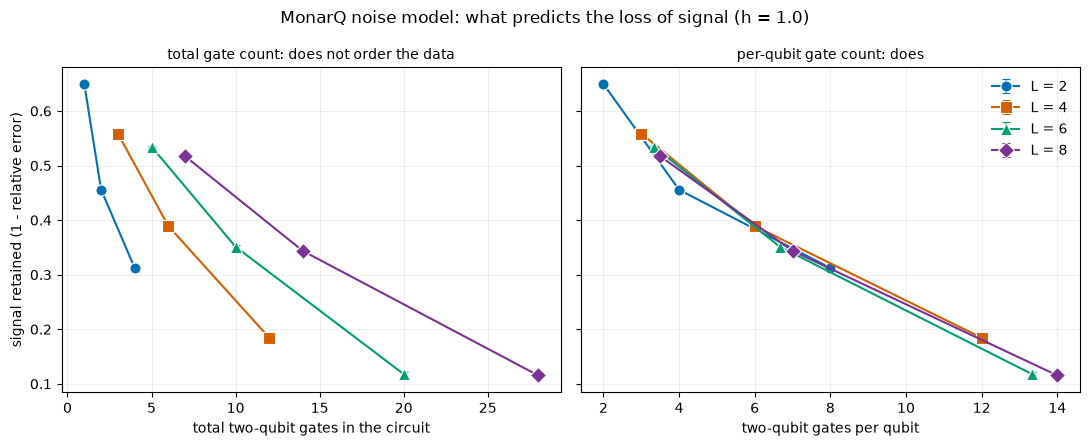

In [7]:
fig, (ax_total, ax_per_qubit) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for L in (2, 4, 6, 8):
    pts = sorted((r["two_qubit_gate_count"], r["n_layers"],
                  1 - r["rel_error_hardware_sim"], r["rel_error_hardware_sim_standard_error"])
                 for r in records.values() if r["L"] == L and r["h"] == 1.0)
    gates, layers, retained, sem = zip(*pts)
    # Each IsingZZ transpiles to 2 native CZ, shared across L qubits.
    per_qubit = [4 * (L - 1) * n / L for n in layers]
    for ax, x in ((ax_total, gates), (ax_per_qubit, per_qubit)):
        ax.errorbar(x, retained, yerr=sem, marker=MARKERS[L], color=COLORS[L], markersize=8,
                    markeredgecolor="white", markeredgewidth=0.8, linewidth=1.5,
                    capsize=3, label=f"L = {L}")

ax_total.set_xlabel("total two-qubit gates in the circuit")
ax_per_qubit.set_xlabel("two-qubit gates per qubit")
ax_total.set_ylabel("signal retained (1 - relative error)")
ax_total.set_title("total gate count: does not order the data", fontsize=10)
ax_per_qubit.set_title("per-qubit gate count: does", fontsize=10)
for ax in (ax_total, ax_per_qubit):
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
ax_per_qubit.legend(frameon=False)
fig.suptitle("MonarQ noise model: what predicts the loss of signal (h = 1.0)")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_noise_vs_gates.png", dpi=150)
plt.show()

Two things change once the baselines are trained properly.

The three repaired points drop sharply: `L=4`/1 layer from 97.0% to 44.1%, `L=6`/1 layer from 81.1% to 46.5%, `L=6`/2 layers from 88.7% to 64.9%. What was previously read as noise bad enough to erase the signal at low depth was mostly a badly-trained state.

More importantly, the corrected data does not support the conclusion drawn from the old version. That conclusion was that error lands in a similar place at matched two-qubit gate count regardless of `L`, and therefore that gate count is what drives the degradation. Sorted by total two-qubit gate count, the corrected retentions are not even monotonic:

| total 2q gates | 1 | 2 | 3 | 4 | 5 | 6 | 10 | 12 | 20 |
|---|---|---|---|---|---|---|---|---|---|
| signal retained | 0.649 | 0.456 | **0.559** | 0.312 | **0.535** | 0.389 | 0.351 | 0.184 | 0.118 |

Three gates (`L=4`, 1 layer) retains *more* signal than two (`L=2`, 2 layers), and five (`L=6`, 1 layer) retains more than four (`L=2`, 4 layers). Total gate count does not order the data.

Two-qubit gates **per qubit** does, monotonically and without exception — and it collapses the three `L` curves onto essentially a single line, which is the clearest way to see it in the right panel below. Each `IsingZZ` transpiles to 2 native `CZ`, so the circuit carries `2(L−1)n` CZ gates spread across `L` qubits — `4(L−1)n/L` each. That is `2n` at `L=2`, `3n` at `L=4` and `3.33n` at `L=6`: proportional to depth, but saturating in `L` towards `4n`. Which is exactly the observed behaviour. Quadrupling the depth is expensive; tripling the qubit count at fixed depth costs comparatively little.

Signal retention is the natural framing rather than "% error" because ⟨H⟩ = 0 for the maximally mixed state — every Pauli term is traceless — so zero retention is what total decoherence looks like, not an arbitrary reference point.

One more thing worth knowing before reading any number from this device. `monarq.sim` models gate noise as depolarizing channels and nothing else. `GateNoiseSimulation` computes amplitude- and phase-damping parameters from the calibration's T1 and T2 values and then never applies them:

In [8]:
from collections import Counter

from pennylane.tape import QuantumTape
from pennylane_calculquebec.processing import PreProcessor
from pennylane_calculquebec.processing.config import MonarqDefaultConfig
from pennylane_calculquebec.processing.steps import GateNoiseSimulation
from src.vqe import hva_layer

# Build the L=6 / 4-layer circuit, transpile it the way the device would, add the
# noise the device would add, then count what actually ended up in the tape.
with qml.queuing.AnnotatedQueue() as q:
    for w in range(6):
        qml.Hadamard(wires=w)
    for _ in range(4):
        hva_layer(0.7, 0.3, 6)
    qml.counts(wires=[0, 1])

tape = QuantumTape(*qml.queuing.process_queue(q), shots=1000)
config = MonarqDefaultConfig(MACHINE_NAME, use_benchmark=False)
transpiled = PreProcessor.get_processor(config, list(range(6)))(tape)[0][0]
noisy = GateNoiseSimulation(MACHINE_NAME, False).execute(transpiled)

print("operations in the tape monarq.sim hands to default.mixed:")
for name, count in sorted(Counter(op.name for op in noisy.operations).items(), key=lambda kv: -kv[1]):
    tag = "  <- noise" if "Channel" in name or "Damping" in name else ""
    print(f"  {name:<22}{count:>5}{tag}")

# The depolarizing probabilities come from `singleQubitGateFidelity`, measured with
# one qubit driven at a time. The payload also carries the parallel figure, measured
# with the others driven alongside — which is what a multi-qubit circuit does.
print("\nsingle-qubit gate fidelity, and the depolarizing probability it implies:")
print(f"  {'qubit':<8}{'isolated':>10}{'parallel':>10}{'p used':>10}{'p implied':>12}")
for q in sorted(usable_qubits, key=int):
    v = calibration["qubits"][q]
    iso, par = v["singleQubitGateFidelity"], v["parallelSingleQubitGateFidelity"]
    print(f"  q{q:<7}{iso:>10.4f}{par:>10.4f}{1 - iso:>10.4f}{1 - par:>12.4f}")

operations in the tape monarq.sim hands to default.mixed:
  DepolarizingChannel     310  <- noise
  X90                     118
  PauliZ                   68
  RZ                       44
  CZ                       40

single-qubit gate fidelity, and the depolarizing probability it implies:
  qubit     isolated  parallel    p used   p implied
  q9          0.9956    0.9933    0.0044      0.0067
  q10         0.9956    0.9887    0.0044      0.0113
  q11         0.9953    0.9931    0.0047      0.0069
  q12         0.9943    0.9932    0.0057      0.0068
  q13         0.9972    0.9834    0.0028      0.0166
  q14         0.9941    0.9923    0.0059      0.0077


`DepolarizingChannel` and nothing else. The simulator therefore has no time- or idle-dependent error at all, which is one concrete reason it should be expected to underestimate real hardware — and a reason its noise is a function of gate counts by construction, which is worth remembering when reading the per-qubit result below.

The second column of the fidelity table is a related gap. The depolarizing probabilities are built from `singleQubitGateFidelity`, which is measured one qubit at a time. MonarQ also reports `parallelSingleQubitGateFidelity`, measured with the neighbouring qubits driven simultaneously — which is what every circuit here does — and it is 2 to 5 points worse. Since the probability is `1 − fidelity`, using the isolated figure understates single-qubit gate noise by a factor of 6 to 14 depending on the qubit. Both omissions push the same way, and neither is visible in the model's output.

### What predicts the damage

The `h = 1.0` ladder above suggests per-qubit gate load rather than total gate count, but with three system sizes at one field strength that is a pattern, not a result. Two additions make it a test.

`L = 8` is the sharp one, because the two candidate variables disagree about it. One layer at `L=8` needs 7 two-qubit gates — more than any other single-layer circuit here — but only 3.5 per qubit, which is *fewer* than the 4.0 that two layers at `L=2` puts on each of its two qubits. Total gate count says `L=8`/1 layer should fare worse than `L=2`/2 layers; per-qubit count says better. They cannot both be right.

The whole scan was then repeated at `h = 0.4` and `h = 1.6`, giving 30 points in total.

One methodological point has to come first, because it changes the answer. Measuring against the *exact* ground state conflates two different things wherever the ansatz cannot reach it — and at `h = 0.4` it often cannot, by over 20% at one layer. That is much larger than the differences being compared, and judged that way the per-qubit ordering appears to break at `h = 0.4`. It does not; the metric does. Dividing the noisy energy by the circuit's *own noiseless* energy isolates what the device did to that circuit, which is the quantity a claim about noise needs.

In [9]:
def per_qubit_gates(L, n_layers):
    """Two-qubit gates each qubit sees: 2(L-1)n native CZ shared across L qubits."""
    return 4 * (L - 1) * n_layers / L


def damping(record):
    """What the device did to this particular circuit: E_noisy / E_noiseless.

    Relative error against *exact* is the wrong quantity for a claim about noise,
    because wherever the ansatz cannot reach the ground state it folds the
    variational gap in with the device error. At h=0.4 with one layer that gap is
    over 20%, far larger than the differences being compared. Dividing by the
    circuit's own noiseless energy isolates the device.
    """
    values = [v / record["E0_sim_noiseless"] for v in record["E0_hardware_sim_values"]]
    return float(np.mean(values)), float(np.std(values, ddof=1) / np.sqrt(len(values)))


rows = []
for r in records.values():
    mean, sem = damping(r)
    rows.append({"L": r["L"], "h": r["h"], "n_layers": r["n_layers"],
                 "gates": r["two_qubit_gate_count"],
                 "per_qubit": per_qubit_gates(r["L"], r["n_layers"]),
                 "damping": mean, "sem": sem})

# Head-to-head. These two points are ordered one way by total gate count and the
# other way by per-qubit count, so they separate the two explanations directly.
big = next(r for r in rows if (r["L"], r["h"], r["n_layers"]) == (8, 1.0, 1))
deep = next(r for r in rows if (r["L"], r["h"], r["n_layers"]) == (2, 1.0, 2))
print("head-to-head at h = 1.0")
print(f"  L=8, 1 layer : {big['gates']:>2} gates total, {big['per_qubit']:.2f} per qubit"
      f"  ->  damping {big['damping']:.3f} +/- {big['sem']:.3f}")
print(f"  L=2, 2 layers: {deep['gates']:>2} gates total, {deep['per_qubit']:.2f} per qubit"
      f"  ->  damping {deep['damping']:.3f} +/- {deep['sem']:.3f}")
print("  total gate count predicts L=8 fares worse; per-qubit count predicts better")
sep = (big["damping"] - deep["damping"]) / (big["sem"] ** 2 + deep["sem"] ** 2) ** 0.5
print(f"  -> per-qubit count is right, by {sep:.0f} standard errors")

print("\ndoes damping fall monotonically when the points are sorted by...")
print(f"{'':>9}{'total gates':>22}{'gates per qubit':>18}{'points':>9}")
for h in (0.4, 1.0, 1.6):
    at_h = [r for r in rows if r["h"] == h]
    verdicts = []
    for key in ("gates", "per_qubit"):
        seq = [r["damping"] for r in sorted(at_h, key=lambda r: r[key])]
        inversions = sum(1 for a, b in zip(seq, seq[1:]) if b > a)
        verdicts.append("yes" if inversions == 0 else f"no ({inversions} inversions)")
    print(f"  h={h:<6}{verdicts[0]:>22}{verdicts[1]:>18}{len(at_h):>9}")

head-to-head at h = 1.0
  L=8, 1 layer :  7 gates total, 3.50 per qubit  ->  damping 0.537 +/- 0.001
  L=2, 2 layers:  2 gates total, 4.00 per qubit  ->  damping 0.456 +/- 0.005
  total gate count predicts L=8 fares worse; per-qubit count predicts better
  -> per-qubit count is right, by 16 standard errors

does damping fall monotonically when the points are sorted by...
                    total gates   gates per qubit   points
  h=0.4        no (2 inversions)               yes        9
  h=1.0        no (4 inversions)               yes       12
  h=1.6        no (2 inversions)               yes        9


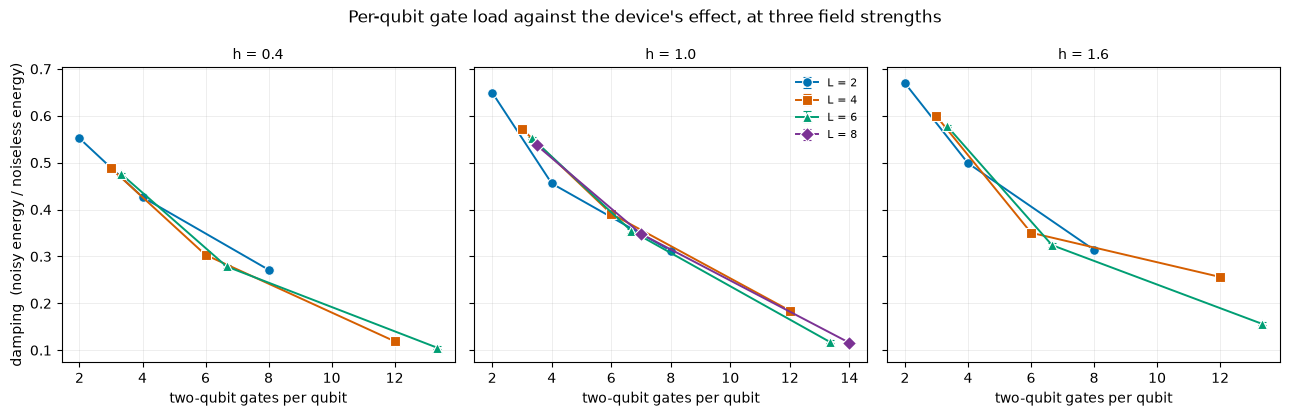

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, h in zip(axes, (0.4, 1.0, 1.6)):
    for L in (2, 4, 6, 8):
        pts = sorted((r["per_qubit"], r["damping"], r["sem"])
                     for r in rows if r["L"] == L and r["h"] == h)
        if not pts:
            continue
        x, y, err = zip(*pts)
        ax.errorbar(x, y, yerr=err, marker=MARKERS[L], color=COLORS[L], markersize=7,
                    markeredgecolor="white", markeredgewidth=0.8, linewidth=1.4,
                    capsize=3, label=f"L = {L}")
    ax.set_title(f"h = {h}", fontsize=10)
    ax.set_xlabel("two-qubit gates per qubit")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel("damping  (noisy energy / noiseless energy)")
# legend goes on the h=1.0 panel: it is the only one with an L=8 series
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle("Per-qubit gate load against the device's effect, at three field strengths")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_noise_collapse.png", dpi=150)
plt.show()

Both tests come out the same way.

`L=8` at one layer is damped to 0.537 ± 0.001 against 0.456 ± 0.005 for `L=2` at two layers — the point with 3.5× the total gate count is the *less* damaged one, by 16 standard errors. Total gate count predicted the opposite.

Across all 30 points, per-qubit gate load orders the data monotonically at every field strength, with no inversions anywhere. Total gate count fails at all three. So the claim is not a fit to one field strength — the same variable orders the noise in the ferromagnetic, critical and paramagnetic regimes alike.

The mechanism is straightforward once stated. Each `IsingZZ` becomes 2 native `CZ`, and a chain of `L` qubits carries `2(L−1)n` of them spread across `L` qubits: `4(L−1)n/L` each. That is `2n` at `L=2` and `4n` in the limit of large `L`, so it doubles over the whole range of system size while growing without bound in depth. Adding qubits at fixed depth spreads the gates out; adding layers piles them onto every qubit at once. Depth is the binding constraint and qubit count only a secondary one, which is the opposite of how a total-gate-count budget would read the same circuits.

Two honest limits. This is the noise *model*, not the machine — and the model has no relaxation or dephasing, so it is a gate-counting model by construction, which is part of why a gate-counting variable describes it so well. Whether it orders real hardware is tested directly below.

### Does it survive on the machine?

Everything above is the noise *model*. The model has no relaxation, no dephasing, and reads
isolated rather than parallel gate fidelities, so a variable built out of gate counts describing
it well is close to circular. The question that matters is whether per-qubit gate load also
orders the real device.

That is testable, and cheap: one layer at `L = 4` and `L = 6` on `monarq.default`, five repeats
each, against the `L = 2` point already measured. The prediction was written down first. Take
the ratio of hardware damping to calibrated-simulator damping at `L = 2`, assume it holds at
larger `L`, and that gives a null. Because per-qubit gate load rises with `L` — 2, 3 and 3.33
at one layer — and because the simulator uses isolated fidelities where the parallel figure is
the binding one for simultaneously driven qubits, the expectation was that hardware would come
in *below* that null, and further below at `L=6` than at `L=4`.

In [11]:
import glob
import math

def hardware_damping(pattern):
    """Mean and standard error of E_noisy / E_noiseless over the repeats matching a glob."""
    values = []
    for f in sorted(glob.glob(pattern)):
        r = json.loads(Path(f).read_text())
        values.append(r["E0"] / r["E0_sim_noiseless"])
    return float(np.mean(values)), float(np.std(values, ddof=1) / np.sqrt(len(values))), len(values)

# Calibrated-simulator damping for the same three circuits, measured earlier in this notebook's
# companion runs; the L=2 anchor turns these into a prediction for L=4 and L=6.
CAL_SIM = {2: (0.737, 0.005), 4: (0.663, 0.004), 6: (0.633, 0.002)}

hw = {2: hardware_damping(str(REPO_ROOT / "results/vqe_hardware/2/1.000_layers1_rep*_default*.json")),
      4: hardware_damping(str(REPO_ROOT / "results/vqe_hardware/4/*_ladder.json")),
      6: hardware_damping(str(REPO_ROOT / "results/vqe_hardware/6/*_ladder.json"))}

ratio = hw[2][0] / CAL_SIM[2][0]
ratio_rel = math.hypot(hw[2][1] / hw[2][0], CAL_SIM[2][1] / CAL_SIM[2][0])

print(f"L=2 anchor: hardware {hw[2][0]:.3f} +/- {hw[2][1]:.3f}, calibrated sim {CAL_SIM[2][0]:.3f}"
      f"  ->  ratio {ratio:.3f} +/- {ratio * ratio_rel:.3f}\n")
print(f"{'point':<8}{'predicted null':>20}{'measured':>20}{'outcome':>22}")
for L in (4, 6):
    mean, sem, n = hw[L]
    null = ratio * CAL_SIM[L][0]
    null_err = null * math.hypot(ratio_rel, CAL_SIM[L][1] / CAL_SIM[L][0])
    sigma = (mean - null) / math.hypot(sem, null_err)
    print(f"L={L:<7}{f'{null:.3f} +/- {null_err:.3f}':>20}"
          f"{f'{mean:.3f} +/- {sem:.3f}':>20}{f'{sigma:+.1f} sigma above':>22}")

print("\nhow far the noise model undershoots the machine, by register size:")
for L in (2, 4, 6):
    print(f"  L={L}: {CAL_SIM[L][0] / hw[L][0]:.2f}x   "
          f"(per-qubit gate load {4 * (L - 1) / L:.2f})")

L=2 anchor: hardware 0.294 +/- 0.018, calibrated sim 0.737  ->  ratio 0.399 +/- 0.025

point         predicted null            measured               outcome
L=4           0.264 +/- 0.017     0.375 +/- 0.017      +4.6 sigma above
L=6           0.253 +/- 0.016     0.345 +/- 0.009      +5.1 sigma above

how far the noise model undershoots the machine, by register size:
  L=2: 2.51x   (per-qubit gate load 2.00)
  L=4: 1.77x   (per-qubit gate load 3.00)
  L=6: 1.84x   (per-qubit gate load 3.33)


**The prediction failed, in the direction that falsifies it.** Both points came in above the
null rather than below — 4.6 and 5.1 standard errors above, once the null's own uncertainty is
propagated. Hardware does not degrade faster than the model as the register grows; it degrades
slower. The model undershoots by 2.5× at `L=2` but only about 1.8× at `L=4` and `L=6`.

The reason is one bad qubit. The per-term breakdown shows the term landing on one particular
physical qubit comes back almost dead at every register size — logical site 0 at `L=4`, logical
site 1 at `L=6`, different logical index, same physical qubit. What changes with `L` is only how
much that one site is *diluted*: at `L=2` it is half the register and dominates the energy, at
`L=6` it is one of six and five healthier sites average it down.

So the `L=2` hardware point was never the clean baseline the earlier framing took it for. It is
the noisiest possible sample of device error, because a two-qubit register gives a single bad
qubit half the weight — and everything derived from it inherits that, including the
model-underestimate multiplier, which is why it falls from 2.5× to 1.8× as soon as the register
grows.

**What this does and does not say about per-qubit gate load.** It is tempting to read the same
three points as a refutation, since load rises 2 → 3 → 3.33 while damping goes 0.294 → 0.375 →
0.348. That reading does not hold up. Only one of the three pairwise comparisons is a genuine
inversion: `L=2` sits below both larger registers, at 3.2 and 2.7 standard errors. `L=4` and
`L=6` are 1.4 standard errors apart — unresolved, and in the direction load predicts. And the
single deviant point is the one already explained by the bad qubit, so it cannot also be counted
as evidence that load is the wrong variable. Comparing across register sizes changes which
physical qubits are involved as well as the load, which makes it the wrong comparison for
isolating either.

Two comparisons do isolate them. The 30-point ladder above holds qubit identity fixed by
construction — with `use_benchmark=False` every qubit and coupler gets the same noise
parameters, so load is the only thing that can vary, and it orders the data without exception.
The `L=2` depth scan below is the hardware counterpart: one physical pair throughout, load
varying 2 → 4 → 8.

In [12]:
import collections

def depth_scan(arm):
    """Damping at each depth for one physical qubit pair, pooled over repeats."""
    points = collections.defaultdict(list)
    for f in glob.glob(str(REPO_ROOT / f"results/vqe_hardware/2/*_rep*_{arm}.json")):
        if "bloch" in f:
            continue
        r = json.loads(Path(f).read_text())
        points[(r["h"], r["n_layers"])].append(r["E0"] / r["E0_sim_noiseless"])
    return {k: (float(np.mean(v)), float(np.std(v, ddof=1) / np.sqrt(len(v))))
            for k, v in points.items()}

for arm, label in (("best", "qubits 13-10, no anomalous qubit"),
                   ("default", "qubits 9-12, contains the anomalous one")):
    scan = depth_scan(arm)
    print(f"{arm} pair ({label})")
    for lo, hi, name in ((1, 2, "load 2 -> 4"), (2, 4, "load 4 -> 8")):
        parts = []
        for h in (0.4, 1.0, 1.6):
            (m_lo, e_lo), (m_hi, e_hi) = scan[(h, lo)], scan[(h, hi)]
            diff, err = m_hi - m_lo, math.hypot(e_lo, e_hi)
            parts.append(f"h={h}: {diff:+.3f} ({abs(diff / err):.1f}s "
                         f"{'ok' if diff < 0 else 'against'})")
        print(f"   {name}:  " + "   ".join(parts))
    print()

# Why the pair containing the anomalous qubit is not a clean test: the error on
# that qubit is itself depth-dependent, because each depth trains to different angles.
per_depth = collections.defaultdict(list)
for f in glob.glob(str(REPO_ROOT / "results/vqe_hardware/2/*_rep*_default*.json")):
    if "bloch" in f:
        continue
    r = json.loads(Path(f).read_text())
    for t in r.get("terms", []):
        if t["term"].startswith("X(0)"):
            per_depth[r["n_layers"]].append(t["expval"])

print("the anomalous qubit's own term, by depth (noiseless value is positive at every depth):")
for n_layers in sorted(per_depth):
    v = per_depth[n_layers]
    print(f"   {n_layers} layer(s): {np.mean(v):+.3f} +/- {np.std(v, ddof=1) / np.sqrt(len(v)):.3f}"
          f"  (n={len(v)})")

best pair (qubits 13-10, no anomalous qubit)
   load 2 -> 4:  h=0.4: -0.077 (3.4s ok)   h=1.0: -0.091 (5.5s ok)   h=1.6: -0.112 (9.0s ok)
   load 4 -> 8:  h=0.4: -0.455 (24.9s ok)   h=1.0: -0.526 (26.3s ok)   h=1.6: -0.499 (32.4s ok)

default pair (qubits 9-12, contains the anomalous one)
   load 2 -> 4:  h=0.4: -0.020 (0.7s ok)   h=1.0: +0.048 (1.7s against)   h=1.6: +0.019 (0.6s against)
   load 4 -> 8:  h=0.4: -0.040 (1.3s ok)   h=1.0: -0.168 (5.4s ok)   h=1.6: -0.156 (5.8s ok)

the anomalous qubit's own term, by depth (noiseless value is positive at every depth):
   1 layer(s): -0.141 +/- 0.020  (n=21)
   2 layer(s): +0.236 +/- 0.012  (n=15)
   4 layer(s): +0.092 +/- 0.015  (n=15)


With placement genuinely held fixed, load orders the hardware without exception. On the
13-10 pair every step runs the predicted way, from 3.4 standard errors at the smallest to
32 at the largest. There is no unresolved step and no violation.

The other pair is messier, and the reason is the same qubit for a third time. Holding the
*qubits* fixed does not hold the *error* fixed there, because the anomalous qubit's damage is
itself depth-dependent — its term runs −0.141, +0.236, +0.092 across one, two and four layers,
since each depth trains to different angles and lands the Bloch vector somewhere else. So that
scan mixes a change in load with a change in rotation, and that is exactly where its two
anomalies sit, including the step that runs against the prediction. Not noise, a confound.

The synthesis is therefore narrower than "load predicts the machine" and wider than "load fails
on hardware". Per-qubit gate load is necessary and not sufficient. It orders the noise model
without exception — unsurprising, since that model gives every qubit identical parameters and so
has no other variable to express. It orders real hardware too, decisively, once the physical
qubits and their error are genuinely held constant. What it cannot survive is a change of
placement: at `L=2` the lowest-load circuit is the most damaged of the three, by 3.2 standard
errors, because one pathological qubit carries half of a two-qubit register.

Which qubits a circuit lands on can outweigh how many gates each of them sees, and nothing in
the calibration payload flags which qubits those are — the anomalous one is the best-rated on
the chip. For a two-qubit register that is the difference between retaining 29% of the signal
and 46%. The practical consequence is that small-register benchmarking on this device measures
whichever qubits the transpiler happened to choose, and the transpiler chooses silently.

## Does readout error mitigation help?

The plugin ships `MatrixReadoutMitigation`, a calibration-matrix correction applied to the measured counts after a circuit runs. An earlier pass through this notebook appended it to the processing config, saw the energy barely move, and concluded that mitigation does not help here.

That conclusion was not supported, because the correction never ran. `MatrixReadoutMitigation.execute` wraps its body in `try/except`, logs whatever went wrong, and hands back the counts it was given — so a correction that failed outright looks exactly like one that ran and found nothing to fix. Two separate things were going wrong, and both were silent:

In [13]:
from pennylane.measurements import CountsMP
from pennylane.tape import QuantumTape
from pennylane_calculquebec.processing.steps.readout_error_mitigation import MatrixReadoutMitigation

counts = {"00": 500, "01": 100, "10": 100, "11": 300}

for wires, note in (([0, 1], "logical wires — MonarQ is not calibrating these"),
                    ([9, 10], "real qubits from the live chain")):
    # The plugin caches its calibration matrix on the class and only reconsiders
    # it once a day, so it has to be cleared between different sets of qubits.
    MatrixReadoutMitigation._readout_matrix_normalized = None
    MatrixReadoutMitigation._readout_matrix_reduced = None
    MatrixReadoutMitigation._readout_matrix_reduced_inverted = None

    tape = QuantumTape(ops=[], measurements=[CountsMP(wires=wires)], shots=1000)
    out = MatrixReadoutMitigation(MACHINE_NAME).execute(tape, counts)
    changed = any(out[k] != counts[k] for k in counts)
    print(f"wires {wires}  ({note})")
    print(f"    in : {counts}")
    print(f"    out: {dict((k, float(v)) for k, v in out.items())}")
    print(f"    counts changed: {changed}")

wires [0, 1]  (logical wires — MonarQ is not calibrating these)
    in : {'00': 500, '01': 100, '10': 100, '11': 300}
    out: {'00': 500.0, '01': 100.0, '10': 100.0, '11': 300.0}
    counts changed: False
wires [9, 10]  (real qubits from the live chain)
    in : {'00': 500, '01': 100, '10': 100, '11': 300}
    out: {'00': 514.0, '01': 18.0, '10': 65.0, '11': 403.0}
    counts changed: True


1. **No client.** `qml.device("monarq.sim", wires=L)` was built without one, so the plugin's `ApiAdapter` was never initialized and the calibration lookup raised before any correction could happen.
2. **Dead qubits.** Even with a client, a circuit left on logical wires `0..L-1` reads its calibration off qubits MonarQ is not currently running. Those report all-zero fidelities, the readout matrix comes out degenerate, and the correction is skipped — the first line above. It only works once the circuit sits on the live chain, which is the second line.

The numbers the earlier run reported as "mitigated" (35.96% → 35.33% at `L=2`, 79.62% → 80.85% at `L=6`) were therefore two runs of the same *unmitigated* pipeline, differing only by shot noise.

`src/mitigation.py` fixes this. `VerifiedReadoutMitigation` checks the calibration before correcting, clears that class-level cache between Hamiltonian terms (consecutive terms measure different qubits), records what it did on every circuit, and `raise_if_not_applied` turns a skipped correction into an error. The check has to be made from outside the plugin, which swallows exceptions raised inside a processing step too:

In [14]:
# The old call pattern. Without a client the correction cannot run, and this
# used to return a number that looked mitigated. Now it refuses.
try:
    measure_raw_and_mitigated(L=2, h=1.0, params=np.zeros((1, 2)), client=None)
    print("no guard fired — mitigation silently did nothing")
except RuntimeError as exc:
    print(f"guard fired: {exc}")

guard fired: readout mitigation did not apply on 3 of 3 circuits — wires [0, 4]: qubits [0, 4] report zero readout fidelity — not currently calibrated; wires [0]: qubits [0] report zero readout fidelity — not currently calibrated; wires [4]: qubits [4] report zero readout fidelity — not currently calibrated


## Mitigation, measured properly

With a client the correction genuinely applies, and one run gives both numbers. Readout mitigation is pure post-processing of measured counts, so the raw and mitigated energies can be computed from the *same shots* — which takes shot noise out of the comparison entirely, leaving only the correction. Each point is still repeated 10 times so both arms carry a real error bar, and the paired difference (mitigated minus raw, repeat by repeat) is the sharper statistic of the two.

Two caveats have to be stated plainly, because together they bound what this result means.

**The simulator flatters mitigation.** `monarq.sim` injects readout noise using the same per-qubit calibration matrix the mitigation step inverts, so on the simulator the correction is exact by construction. What it recovers is the readout-error share of the total error — an upper bound on what mitigation could achieve on real hardware, not a prediction of it.

**Passing a client changes the noise model.** With one, `monarq.sim` builds its gate and readout noise from MonarQ's live calibration instead of the plugin's generic `TypicalBenchmark` constants. Both arms below use the live model, so the comparison between them is controlled — but these raw energies are not directly comparable to the ladder above, which was measured without a client.

In [15]:
MITIGATION_DIR = REPO_ROOT / "results" / "monarq_mitigation"
MITIGATION_POINTS = [(2, 0.4, 1), (2, 1.0, 1), (2, 1.6, 1),
                     (6, 1.0, 1), (6, 1.0, 2), (6, 1.0, 4)]


def mitigation_path(L, h, n_layers, arm):
    """Where one arm (raw or mitigated) of a mitigation point is stored."""
    return MITIGATION_DIR / str(L) / f"{h:.3f}_layers{n_layers}_{arm}.json"


def run_mitigation_point(L, h, n_layers):
    """Measure one point raw and mitigated from the same shots, N_REPEATS times over."""
    base = records[(L, h, n_layers)]
    _, _, params = train_vqe(L=L, h=h, n_layers=n_layers, n_steps=N_STEPS,
                             stepsize=STEPSIZE, seed=base["best_seed"], return_params=True)
    start = time.perf_counter()
    summary = repeat_raw_and_mitigated(L, h, params, n_repeats=N_REPEATS,
                                       client=client, shots=SHOTS, verbose=False)
    elapsed = time.perf_counter() - start

    E_exact = base["E0_exact"]
    written = {}
    for arm, label in (("raw", "none"), ("mitigated", "matrix_readout")):
        stats = summary[arm]
        record = {
            "L": L, "h": h, "J": 1.0, "n_layers": n_layers,
            "method": "vqe_monarq_sim", "device": "monarq.sim", "boundary": "open",
            "machine_name": MACHINE_NAME,
            "mitigation": label,
            "noise_model": "live_calibration",
            "two_qubit_gate_count": (L - 1) * n_layers,
            "measured_wires": summary["measured_wires"],
            "E0_exact": E_exact,
            "E0_sim_noiseless": base["E0_sim_noiseless"],
            "n_restarts": base["n_restarts"], "seeds": base["seeds"],
            "best_seed": base["best_seed"],
            "n_steps": N_STEPS, "stepsize": STEPSIZE, "shots": SHOTS,
            "n_repeats": summary["n_repeats"],
            "mitigation_verified": summary["mitigation_verified"],
            "n_circuits": summary["n_circuits"],
            "n_counts_moved": summary["n_counts_moved"],
            "E0_values": stats["values"],
            "E0": stats["mean"],
            "E0_std": stats["std"],
            "E0_standard_error": stats["standard_error"],
            "rel_error": abs(stats["mean"] - E_exact) / abs(E_exact),
            "rel_error_standard_error": stats["standard_error"] / abs(E_exact),
            "paired_with_other_arm": True,
            "paired_difference_values": summary["paired_difference"]["values"],
            "paired_difference_mean": summary["paired_difference"]["mean"],
            "paired_difference_standard_error": summary["paired_difference"]["standard_error"],
            "wall_time_s": elapsed,
        }
        path = mitigation_path(L, h, n_layers, arm)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(record, indent=2))
        written[arm] = record
    return written


mitigation = {}
for L, h, n_layers in MITIGATION_POINTS:
    paths = {arm: mitigation_path(L, h, n_layers, arm) for arm in ("raw", "mitigated")}
    if all(p.exists() for p in paths.values()):
        mitigation[(L, h, n_layers)] = {a: json.loads(p.read_text()) for a, p in paths.items()}
        continue
    mitigation[(L, h, n_layers)] = run_mitigation_point(L, h, n_layers)

print(f"{'point':<24}{'raw error':>18}{'mitigated error':>20}{'paired dE (mit - raw)':>26}")
for key in MITIGATION_POINTS:
    raw, mit = mitigation[key]["raw"], mitigation[key]["mitigated"]
    label = f"L={key[0]}  h={key[1]}  layers={key[2]}"
    raw_s = f"{raw['rel_error']:.1%} +/- {raw['rel_error_standard_error']:.1%}"
    mit_s = f"{mit['rel_error']:.1%} +/- {mit['rel_error_standard_error']:.1%}"
    diff = f"{mit['paired_difference_mean']:+.4f} +/- {mit['paired_difference_standard_error']:.4f}"
    print(f"{label:<24}{raw_s:>18}{mit_s:>20}{diff:>26}")
print()
first = mitigation[MITIGATION_POINTS[0]]["mitigated"]
print("physical qubits measured on:", first["measured_wires"])
moved = sum(mitigation[p]["mitigated"]["n_counts_moved"] for p in MITIGATION_POINTS)
total = sum(mitigation[p]["mitigated"]["n_circuits"] for p in MITIGATION_POINTS)
print(f"corrections verified as applied on all {total} circuits; "
      f"the counts actually moved on {moved} of them")

point                            raw error     mitigated error     paired dE (mit - raw)
L=2  h=0.4  layers=1        33.7% +/- 0.6%      22.8% +/- 0.8%        -0.1404 +/- 0.0025
L=2  h=1.0  layers=1        26.3% +/- 0.5%      20.5% +/- 0.6%        -0.1284 +/- 0.0030
L=2  h=1.6  layers=1        24.4% +/- 0.3%      20.2% +/- 0.3%        -0.1390 +/- 0.0021
L=6  h=1.0  layers=1        38.0% +/- 0.4%      31.7% +/- 0.5%        -0.4635 +/- 0.0097
L=6  h=1.0  layers=2        55.3% +/- 0.4%      52.4% +/- 0.5%        -0.2148 +/- 0.0094
L=6  h=1.0  layers=4        86.5% +/- 0.3%      90.8% +/- 0.4%        +0.3155 +/- 0.0073

physical qubits measured on: [[9, 12], [9], [12]]
corrections verified as applied on all 420 circuits; the counts actually moved on 416 of them


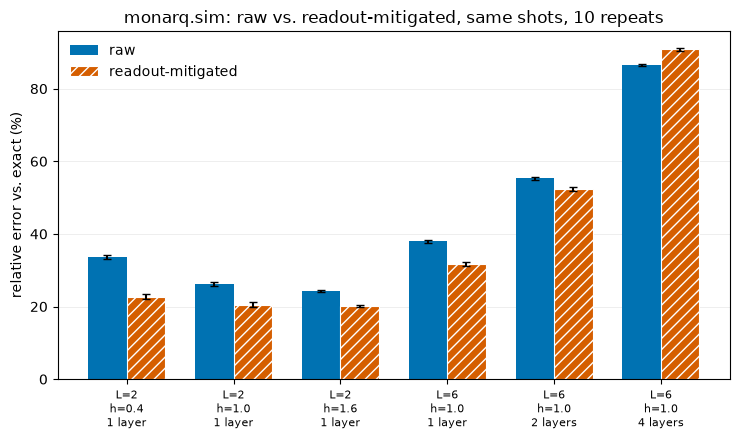

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(MITIGATION_POINTS))
width = 0.36
labels = [f"L={L}\nh={h}\n{n} layer" + ("s" if n > 1 else "") for L, h, n in MITIGATION_POINTS]
raw_err = [mitigation[p]["raw"]["rel_error"] * 100 for p in MITIGATION_POINTS]
raw_sem = [mitigation[p]["raw"]["rel_error_standard_error"] * 100 for p in MITIGATION_POINTS]
mit_err = [mitigation[p]["mitigated"]["rel_error"] * 100 for p in MITIGATION_POINTS]
mit_sem = [mitigation[p]["mitigated"]["rel_error_standard_error"] * 100 for p in MITIGATION_POINTS]

ax.bar(x - width / 2, raw_err, width, yerr=raw_sem, capsize=3, color=RAW_COLOR, label="raw")
ax.bar(x + width / 2, mit_err, width, yerr=mit_sem, capsize=3, color=MITIGATED_COLOR,
       hatch="///", edgecolor="white", linewidth=0.8, label="readout-mitigated")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("relative error vs. exact (%)")
ax.set_title("monarq.sim: raw vs. readout-mitigated, same shots, 10 repeats")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_readout_mitigation.png", dpi=150)
plt.show()

Mitigation does help, substantially, at shallow depth — and the effect is far larger than the statistical error, so this is a real measurement rather than the shot-noise difference the earlier run was reading.

| point | raw error | mitigated error | change | paired ΔE |
|---|---|---|---|---|
| `L=2`, h=0.4, 1 layer | 33.73 ± 0.60% | **22.76 ± 0.75%** | −11.0 pp | −0.1404 ± 0.0025 (55σ) |
| `L=2`, h=1.0, 1 layer | 26.28 ± 0.49% | **20.54 ± 0.61%** | −5.7 pp | −0.1284 ± 0.0030 (43σ) |
| `L=2`, h=1.6, 1 layer | 24.39 ± 0.25% | **20.25 ± 0.30%** | −4.1 pp | −0.1390 ± 0.0021 (66σ) |
| `L=6`, h=1.0, 1 layer | 38.02 ± 0.40% | **31.67 ± 0.52%** | −6.3 pp | −0.4635 ± 0.0097 (48σ) |
| `L=6`, h=1.0, 2 layers | 55.35 ± 0.39% | **52.40 ± 0.51%** | −3.0 pp | −0.2148 ± 0.0094 (23σ) |
| `L=6`, h=1.0, 4 layers | 86.50 ± 0.33% | 90.82 ± 0.42% | **+4.3 pp** | **+0.3155 ± 0.0073 (43σ)** |

The benefit decays with depth and then reverses. At one layer the correction recovers 4 to 11 percentage points; by two layers it is down to 3; by four layers it makes the answer measurably *worse*. The reversal is not noise either — it is 43 standard errors on the paired difference.

The mechanism is the same in both directions. The correction amplifies the measured distribution's deviation from the calibration matrix's fixed point. At one layer a real signal survives, so what gets amplified is signal. At four layers only about 12% of the signal is left, so what gets amplified is mostly residual, and the energy is pushed further from the truth. Error mitigation applied to a measurement that has already lost its signal does not bring it back.

The old conclusion has to be dropped in both of its parts. Mitigation is not ineffective here; and the inference drawn from thinking it was — that readout error is ruled out, leaving gate and decoherence noise as the whole story — does not follow. At shallow depth readout error is a real and correctable share of the total. Gate noise still dominates, but it was never the only mechanism.

The two caveats above bound how far this travels, and they matter. The simulator inverts exactly the matrix it used to inject the readout noise, so these are best-case numbers: they measure how much of the error *is* readout error, which is the ceiling on what mitigation could recover, not a prediction of what it would recover on MonarQ itself.

There is a second, sharper reason to expect less on hardware, and it is specific to how the correction is built. The matrix comes from `readoutState0Fidelity` and `readoutState1Fidelity`, measured with one qubit read out at a time. MonarQ also reports the parallel versions, measured with all qubits read out together — which is what happens here — and they are worse, by up to 7 points on state 1. Inverting the isolated matrix against parallel readout error leaves a residual and can push past the physical bound: for a perfectly prepared `|0>` on qubit 13 it returns ⟨Z⟩ = 1.073. On the simulator this never shows up, because the same isolated matrix is used to inject the noise and to remove it.

One further bound comes from the hardware strand rather than from the simulator. At one layer, on the qubit pair the transpiler picks by default, one of the two single-qubit terms comes back with the *wrong sign*, and placing the same circuit on a different pair removes the effect — reproduced over two and a half hours across two independent code paths, though the magnitude moves around too much to quote. A depolarizing channel contracts an expectation value toward zero and can never flip its sign, so at least part of that loss is something the vendor's noise model cannot express, and a calibration-matrix readout correction has no purchase on it either. Splitting each qubit's Bloch vector into how much length it lost and how far it turned settles which: on the default pair the vector turns 119-145° off its noiseless axis *and* keeps only 22-26% of its length, so both channels are present, while on the other pair it barely turns at all (5-11°) and simply shrinks to 43-46%. The distinction is what matters here. A calibration matrix corrects stochastic misassignment at readout time; a rotation that happened before the measurement is invisible to it.

A third caveat is about when these numbers were taken rather than how. Because the calibrated arm reads MonarQ's live calibration, it is tied to the snapshot pulled at run time; the generic-constants ladder further up is not, since those values are hardcoded in the plugin. Whether the device is stable enough for a single session's characterisation to generalise is an open question being looked at separately, and it bears on the calibrated numbers here but not on the ladder.

A small detail from the verification, worth recording because it is what made the guard hard to get right: of the 420 corrections applied across these six points, 416 changed the counts and 4 did not. Both of those were genuine corrections — a distribution already sitting at the calibration matrix's fixed point moves by less than half a count and rounds straight back. That is why `VerifiedReadoutMitigation` decides whether the correction ran by object identity rather than by asking whether the numbers moved.

## Conclusion and hardware plan

The originally-planned `L = 2, 4, 6` ladder at the Phase 1-validated 10-layer depth is not viable. `L=6` already retains only 12% of the energy signal at 4 layers, and per-qubit gate load grows in proportion to depth, so 10 layers is far past the point where anything usable survives.

`L=2` at 1 layer is where the most signal survives — 33.1%, 35.1% and 44.8% error at `h` = 1.6, 1.0 and 0.4 under the generic noise model, and 24-34% under the calibrated one. Still a long way from exact, but a genuine measurement rather than noise-floor garbage, and the HVA reaches the exact ground state there in noiseless simulation, so all of the error is attributable to the device.

Submitted on that basis: `L=2`, `n_layers=1`, `h = 0.4, 1.0, 1.6` (ferromagnetic, critical, paramagnetic), 1000 shots, to the real `monarq.default` backend. Results below.

## Real hardware results

Loading the actual `monarq.default` measurements from `results/vqe_hardware/` alongside the `monarq.sim` prediction for the same exact configuration, to see how well the noise-model simulator actually predicted real hardware behaviour.

h               monarq.sim             hw 9-12            hw 13-10
0.4          44.8 +/- 0.5%       83.1 +/- 1.8%       46.6 +/- 1.5%
1.0          35.1 +/- 0.3%       70.6 +/- 1.8%       37.4 +/- 1.4%
1.6          33.1 +/- 0.5%       65.5 +/- 2.0%       35.6 +/- 0.9%

repeats per point: 7 on the default pair, 7 on 13-10


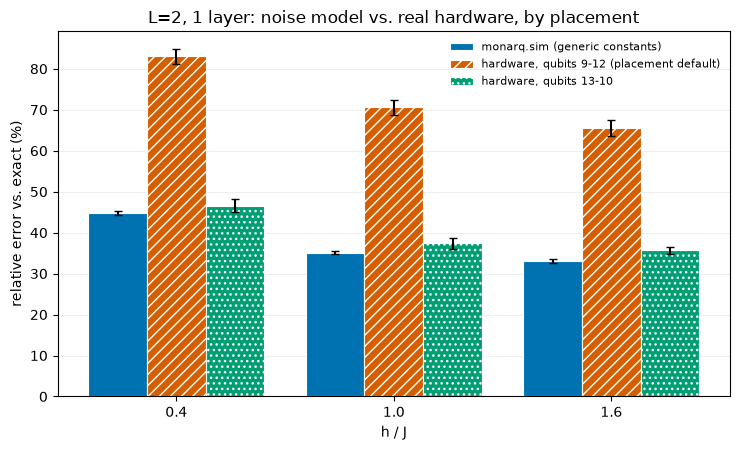

In [17]:
# monarq.sim's prediction against real hardware at L=2, one layer. Both physical
# placements are shown, each pooled over its repeats: the three archived
# single-measurement points this figure used to plot are superseded by these.
def hardware_error(arm, h):
    """Relative error against exact, pooled over every repeat of one arm at one h."""
    errors = []
    for f in glob.glob(str(REPO_ROOT / f"results/vqe_hardware/2/*_layers1_rep*_{arm}.json")):
        if "bloch" in f:
            continue
        r = json.loads(Path(f).read_text())
        if r["h"] != h:
            continue
        errors.append(abs(r["E0"] - r["E0_exact"]) / abs(r["E0_exact"]))
    return float(np.mean(errors)), float(np.std(errors, ddof=1) / np.sqrt(len(errors))), len(errors)

H_VALUES = (0.4, 1.0, 1.6)
SERIES = [
    ("monarq.sim (generic constants)", "#0072B2", None),
    ("hardware, qubits 9-12 (placement default)", "#D55E00", "///"),
    ("hardware, qubits 13-10", "#009E73", "..."),
]

sim = [(records[(2, h, 1)]["rel_error_hardware_sim"] * 100,
        records[(2, h, 1)]["rel_error_hardware_sim_standard_error"] * 100) for h in H_VALUES]
default = [tuple(x * 100 for x in hardware_error("default", h)[:2]) for h in H_VALUES]
best = [tuple(x * 100 for x in hardware_error("best", h)[:2]) for h in H_VALUES]

print(f"{'h':<6}{'monarq.sim':>20}{'hw 9-12':>20}{'hw 13-10':>20}")
for i, h in enumerate(H_VALUES):
    print(f"{h:<6}{f'{sim[i][0]:.1f} +/- {sim[i][1]:.1f}%':>20}"
          f"{f'{default[i][0]:.1f} +/- {default[i][1]:.1f}%':>20}"
          f"{f'{best[i][0]:.1f} +/- {best[i][1]:.1f}%':>20}")
n_def = hardware_error("default", 1.0)[2]
n_best = hardware_error("best", 1.0)[2]
print(f"\nrepeats per point: {n_def} on the default pair, {n_best} on 13-10")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
x = np.arange(len(H_VALUES))
width = 0.27
for offset, (data, (label, color, hatch)) in zip((-width, 0.0, width),
                                                 zip((sim, default, best), SERIES)):
    ax.bar(x + offset, [d[0] for d in data], width, yerr=[d[1] for d in data],
           capsize=3, color=color, label=label,
           hatch=hatch, edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([str(h) for h in H_VALUES])
ax.set_xlabel("h / J")
ax.set_ylabel("relative error vs. exact (%)")
ax.set_title("L=2, 1 layer: noise model vs. real hardware, by placement")
ax.grid(axis="y", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_sim_vs_real.png", dpi=150)
plt.show()

Whether the noise model underestimates real hardware turns out to depend entirely on which qubits the circuit lands on, and that reframes what was previously read off this figure.

On the pair MonarQ's placement heuristic picks by itself, hardware is about twice as bad as the model predicts — 83.1% against 44.8% at `h = 0.4`, 70.6% against 35.1% at `h = 1.0`, 65.5% against 33.1% at `h = 1.6`, a ratio of 1.85 to 2.01. On qubits 13-10 the same comparison nearly vanishes: 46.6% against 44.8%, 37.4% against 35.1%, 35.6% against 33.1%, a ratio of 1.04 to 1.08. The model is accurate to within about two percentage points there.

So "MonarQ's calibration-based noise model underestimates the total error by roughly a factor of two" is not a property of the model. It is a property of the qubits the default placement happened to choose. The earlier version of this section stated the factor-of-two gap as a general finding, on three single-shot measurements taken on the default pair; with repeats and a second placement it is specific to that pair.

The model's omissions are still real and still worth stating — it carries no relaxation or dephasing at all, and it reads isolated rather than parallel gate fidelities, both of which make it optimistic. But at this size and depth, on a pair without the anomalous qubit, neither omission is large enough to show up above the repeat spread. And the agreement on 13-10 is agreement in aggregate only: the model cannot represent the coherent error seen on the other pair at all, since no depolarizing channel can carry an expectation value past zero. A model that gets the total right on one placement and cannot express what goes wrong on another is not validated by the first result.

One bookkeeping point. The three values this figure used to plot were single unrepeated measurements. Repeating them seven times revises them upward and gives them error bars: retention at one layer is 16.9 ± 1.8%, 29.4 ± 1.8% and 34.5 ± 2.0% at `h` = 0.4, 1.0 and 1.6, against the 9%, 26% and 27% recorded originally. The archived `h = 0.4` point sits about 3.4 standard errors from its own repeated mean, so it should not be quoted.

## Measuring each Hamiltonian term separately

Everything above treats the energy as one number. But `evaluate_on_device` never measured it
as one number — it runs one circuit per Hamiltonian term and sums the weighted results, and
then throws the breakdown away. Keeping it costs nothing and says considerably more, because
each term is a different observable and the device does not treat them alike.

For every term the useful quantity is its **damping**, measured value divided by its
noiseless value. 1.0 is a perfect device, 0.0 is total signal loss. Normalising against the
*noiseless circuit* rather than against exact matters: at larger `L` and low depth the ansatz
cannot reach the ground state, and dividing by exact would silently fold that variational gap
into what looks like a device measurement. At `L=2` with one layer the ansatz is exact, so the
two agree, but the habit is the safe one.

Two things were run five to seven times each: `h = 0.4, 1.0, 1.6` at 1, 2 and 4 layers, on the qubit
pair MonarQ's placement heuristic picks by itself, and on qubits 13-10, chosen because that coupler had the
highest advertised CZ fidelity when the run was set up. That turned out to be a good choice
but not for the reason it was made: the coupler survey at the end of this section finds the
advertised figure carries no usable information about how a pair actually performs. The circuits are identical — same trained angles, same transpilation, same depth
15/29/57 and same gate counts — so the only difference between the two runs is which physical
qubits they land on.

A check first, on the simulator, where the earlier three-point fit gave d1 = 0.693 +/- 0.023
and d2 = 0.451 +/- 0.053 for the single- and two-qubit damping. Measuring them directly gives
0.716 +/- 0.013 and 0.440 +/- 0.010 — agreement within about one standard error, so the
fitting procedure was sound and what follows is not an artefact of how it was done.

Damping at 1 layer, pooled over h (21 hardware measurements per arm)

                                        <Z0Z1>              <X0>                <X1>                
hardware, qubits 9-12 (plugin default)  +0.020 +/- 0.021    -0.171 +/- 0.025    +0.953 +/- 0.013    
hardware, qubits 13-10                  +0.474 +/- 0.029    +0.436 +/- 0.013    +0.907 +/- 0.010    
monarq.sim, live calibration            +0.575 +/- 0.015    +0.763 +/- 0.005    +0.829 +/- 0.007    
monarq.sim, generic constants           +0.464 +/- 0.013    +0.655 +/- 0.011    +0.762 +/- 0.006    


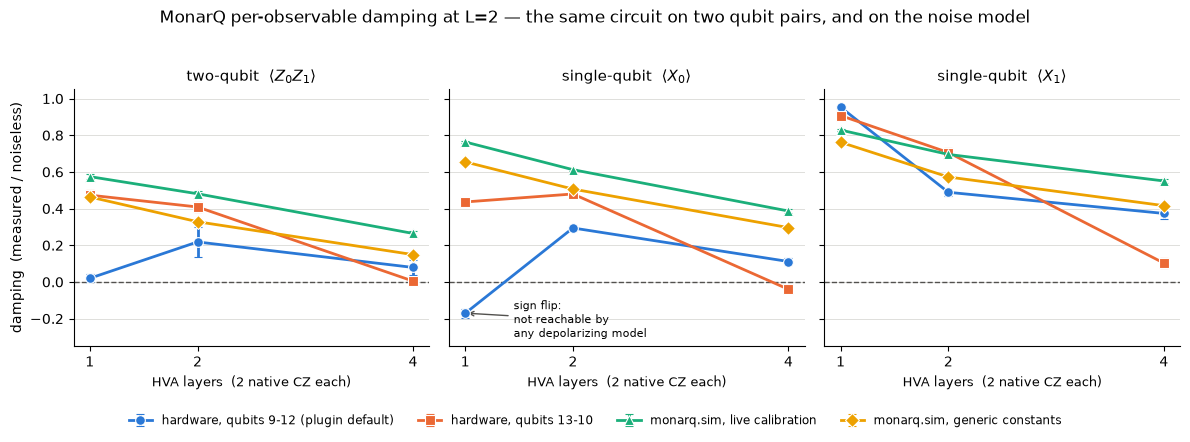

In [18]:
import glob
import math
from collections import defaultdict

PER_TERM_DIRS = ["vqe_hardware", "monarq_sim"]
ARMS = [
    ("default", "hardware, qubits 9-12 (plugin default)", "#2a78d6", "o"),
    ("best", "hardware, qubits 13-10", "#eb6834", "s"),
    ("sim_calibrated", "monarq.sim, live calibration", "#1baf7a", "^"),
    ("sim", "monarq.sim, generic constants", "#eda100", "D"),
]
TERMS = [("Z(0) @ Z(1)", r"two-qubit  $\langle Z_0 Z_1 \rangle$"),
         ("X(0)", r"single-qubit  $\langle X_0 \rangle$"),
         ("X(1)", r"single-qubit  $\langle X_1 \rangle$")]


def pooled_damping():
    """Mean and standard error of each term's damping, pooling every repeat and every h."""
    acc = defaultdict(list)
    for sub in PER_TERM_DIRS:
        for f in glob.glob(str(REPO_ROOT / "results" / sub / "2" / "*_rep*.json")):
            rec = json.loads(Path(f).read_text())
            if "terms" not in rec:      # other per-repeat files live here too
                continue
            for t in rec["terms"]:
                acc[(rec["arm"], rec["n_layers"], t["term"])].append(t["damping"])
    out = {}
    for key, vals in acc.items():
        v = np.asarray(vals, dtype=float)
        out[key] = (v.mean(), v.std(ddof=1) / math.sqrt(len(v)))
    return out


damping = pooled_damping()

n_hw = sum(1 for _ in glob.glob(str(REPO_ROOT / "results" / "vqe_hardware" / "2" / "*_layers1_rep*_default.json")))
print(f"Damping at 1 layer, pooled over h ({n_hw} hardware measurements per arm)\n")
print(f"{'':<40}{'<Z0Z1>':<20}{'<X0>':<20}{'<X1>':<20}")
for arm, label, _, _ in ARMS:
    cells = []
    for term, _ in TERMS:
        m, s = damping[(arm, 1, term)]
        cells.append(f"{m:+.3f} +/- {s:.3f}")
    print(f"{label:<40}" + "".join(f"{c:<20}" for c in cells))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for ax, (term, title) in zip(axes, TERMS):
    for arm, label, colour, marker in ARMS:
        pts = [damping[(arm, n, term)] for n in (1, 2, 4)]
        ax.errorbar([1, 2, 4], [p[0] for p in pts], yerr=[p[1] for p in pts],
                    color=colour, marker=marker, markersize=7, linewidth=2, capsize=3,
                    label=label, zorder=3, markeredgecolor="white", markeredgewidth=0.8)
    ax.axhline(0, color="#52514e", linewidth=1, linestyle="--", zorder=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("HVA layers  (2 native CZ each)", fontsize=9)
    ax.set_xticks([1, 2, 4])
    ax.grid(axis="y", color="#d9d9d6", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("damping  (measured / noiseless)", fontsize=10)
axes[0].set_ylim(-0.35, 1.05)
axes[1].annotate("sign flip:\nnot reachable by\nany depolarizing model",
                 xy=(1, -0.17), xytext=(1.45, -0.30), fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="#52514e", linewidth=1))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8.5, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("MonarQ per-observable damping at L=2 — the same circuit on two qubit pairs, "
             "and on the noise model", fontsize=12, y=1.0)
fig.tight_layout(rect=(0, 0.06, 1, 0.97))
fig.savefig(REPO_ROOT / "figures" / "monarq_per_term_damping.png", dpi=150, bbox_inches="tight")
plt.show()

Three things come out of this, and the first two change what the energy numbers mean.

**The two single-qubit terms are not damaged alike.** They are exactly symmetric in the
noiseless circuit — identical to five decimal places — so any difference between them is the
device. On the default pair one of them survives almost intact at +0.953 +/- 0.013 while the
other comes back at **-0.171 +/- 0.025**, with the wrong sign, in every repeat and at every
field strength. A single averaged "single-qubit damping" of about 0.31, which is what the
earlier three-point fit reported, is the average of those two numbers and describes neither.

A negative damping is worth dwelling on. A depolarizing channel contracts the state toward
the maximally mixed state; it can shrink an expectation value toward zero but it can never
carry it past zero. So this is not the noise model being quantitatively short — it is a kind
of error the model cannot represent at all, which is consistent with the channel census
above finding depolarizing channels and nothing else.

**Which physical qubits you get matters more than anything else measured here.** Moving the
same circuit from the default pair to the 13-10 pair roughly triples the surviving signal
at one layer, from 17-35% to 53-64%, and takes the two-qubit correlator from +0.020 +/- 0.021
— consistent with zero — to +0.474 +/- 0.029, which is emphatically not. The correlator
collapsing to zero was a property of that qubit pair, not of the hardware. The plugin chooses
the pair silently, so none of this is visible in a result file unless you go looking.

**But the best pair is the worse choice at depth.** At four layers the ordering inverts: the
default pair retains 11-21% and the best pair 0-3%. The reason is in the calibration payload.
Both qubits of a two-qubit circuit are driven at the same time, so the figure that binds is
the *parallel* single-qubit fidelity, and for qubit 13 that is 0.9749 against an isolated
0.9962 — a two-point gap, by far the largest of the four qubits involved. Compounded over the
thirteen native rotations per qubit in the four-layer circuit it predicts 0.607 survival for
the best pair against 0.784 for the default pair, which is the inversion, and predicts it
growing with depth. Coherence does not explain it: the best pair has the longer T1 and T2.

The placement heuristic ranks couplers on isolated CZ fidelity and isolated readout fidelity.
It has no access to the parallel figure, so it cannot see this. "Put the circuit on the best
coupler" is good advice at shallow depth and actively wrong at depth, and the advertised
per-qubit numbers do not tell you which regime you are in.

### Is the loss stochastic or coherent?

A negative damping says *something* non-depolarizing is present, but not how much of the
total loss it accounts for. That is separable with three more circuits per point. At `L=2`
the ground state has `<Y> = <Z> = 0` on each qubit by symmetry, so the noiseless Bloch vector
points purely along X. Measuring all three components splits the error in two:

- how much **shorter** the vector got — the stochastic, depolarizing part, which is what the
  noise model represents;
- how far it **turned** off the X axis — the coherent part, which the noise model has no
  channel for at all.

Both qubit pairs, five repeats, one layer.

In [19]:
bloch = defaultdict(list)
for f in glob.glob(str(REPO_ROOT / "results" / "vqe_hardware" / "2" / "bloch_*.json")):
    rec = json.loads(Path(f).read_text())
    bloch[(rec["arm"], rec["h"])].append(rec)


def mean_sem(values):
    v = np.asarray(values, dtype=float)
    return v.mean(), v.std(ddof=1) / math.sqrt(len(v))


print(f"{'qubits':<16}{'h':<6}{'length retained':<22}{'angle off +X axis':<22}")
for arm, pair in (("default", "9-12"), ("best", "13-10")):
    for h in (0.4, 1.0, 1.6):
        recs = bloch[(arm, h)]
        lengths, angles = [], []
        for rec in recs:
            v = np.array([rec["q0_X"], rec["q0_Y"], rec["q0_Z"]])
            lengths.append(np.linalg.norm(v) / rec["q0_len_noiseless"])
            # angle between the measured vector and where it should point
            angles.append(math.degrees(math.atan2(math.hypot(v[1], v[2]), v[0])))
        lm, ls = mean_sem(lengths)
        am, asem = mean_sem(angles)
        print(f"{pair:<16}{h:<6}{lm:.3f} +/- {ls:.3f}         {am:6.1f} +/- {asem:.1f} deg")

qubits          h     length retained       angle off +X axis     
9-12            0.4   0.263 +/- 0.030          119.4 +/- 9.8 deg
9-12            1.0   0.225 +/- 0.020          122.8 +/- 10.7 deg
9-12            1.6   0.233 +/- 0.006          144.7 +/- 10.2 deg
13-10           0.4   0.429 +/- 0.014           11.1 +/- 2.1 deg
13-10           1.0   0.462 +/- 0.005           10.9 +/- 3.8 deg
13-10           1.6   0.463 +/- 0.013            4.7 +/- 1.3 deg


The two pairs fail in different ways, and the split is unambiguous.

On the best pair the vector stays where it should — 5 to 11 degrees off the X axis, which is
consistent with no coherent error at all — and simply gets shorter, retaining 43-46% of its
length. That is depolarization, and it is the behaviour the noise model is built to describe.

On the default pair the vector has turned **119 to 145 degrees**. It is not pointing along X
at all any more, which is why the X component comes back negative: the sign flip is the
shadow of a large coherent rotation, not a strange kind of decay. On top of that it is also
shorter than on the best pair — 22-26% against 43-46% — so qubit 9 carries roughly twice the
stochastic damping *as well as* a coherent error the model cannot express.

So the honest answer is that both channels are present and they are separable. Quoting a
single damping factor per observable, as the earlier fit did, averages a coherent rotation
together with depolarization and reports a number that is neither. It also means readout
error mitigation cannot recover this particular loss: a calibration matrix corrects
stochastic misassignment at measurement time, and a rotation that happened before the
measurement is invisible to it.

### Does the advertised CZ fidelity actually predict anything?

Everything above picked its "good" qubit pair using `czGateFidelity`, the number the plugin's
own placement heuristic ranks on. That was never checked — it was assumed. It is worth
checking, because MonarQ recalibrated partway through this work and the pair used as the good
one had its advertised fidelity drop from 0.9971 to 0.9104, which would make it the *worst*
coupler on the chip rather than the best.

So: the identical circuit, pinned to each of the five usable couplers in turn, five repeats
each.

In [20]:
coupler_runs = defaultdict(lambda: defaultdict(list))
coupler_meta = {}
for f in glob.glob(str(REPO_ROOT / "results" / "vqe_hardware" / "2" / "coupler*_1.000_rep*_perterm.json")):
    rec = json.loads(Path(f).read_text())
    coupler_meta[rec["coupler"]] = (rec["cz_fidelity_at_run"], tuple(rec["wires"]))
    for t in rec["terms"]:
        coupler_runs[rec["coupler"]][t["term"]].append(t["damping"])

# rank the couplers two ways: by what the calibration advertises, and by what we measured
by_cz = sorted(coupler_meta, key=lambda c: -coupler_meta[c][0])
zz = {c: mean_sem(coupler_runs[c]["Z(0) @ Z(1)"]) for c in by_cz}
by_zz = sorted(by_cz, key=lambda c: -zz[c][0])

print(f"{'coupler':<16}{'advertised CZ':<16}{'rank':<7}{'d(ZZ) measured':<22}{'rank'}")
for i, c in enumerate(by_cz):
    cz_val, wires = coupler_meta[c]
    m, s = zz[c]
    print(f"c{c} q{wires[0]}-q{wires[1]:<7}{cz_val:<16.4f}{i + 1:<7}{m:+.3f} +/- {s:.3f}        {by_zz.index(c) + 1}")

x = np.array([coupler_meta[c][0] for c in by_cz])
y = np.array([zz[c][0] for c in by_cz])
r = np.corrcoef(x, y)[0, 1]
print(f"\nPearson r = {r:+.3f} over {len(x)} couplers "
      f"(measured d(ZZ) spans {y.min():+.3f} to {y.max():+.3f})")

coupler         advertised CZ   rank   d(ZZ) measured        rank
c18 q10-q14     0.9670          1      +0.308 +/- 0.040        2
c15 q12-q9      0.9625          2      -0.267 +/- 0.027        5
c16 q9-q13     0.9519          3      +0.055 +/- 0.028        3
c19 q14-q11     0.9406          4      -0.250 +/- 0.051        4
c17 q13-q10     0.9104          5      +0.446 +/- 0.032        1

Pearson r = -0.423 over 5 couplers (measured d(ZZ) spans -0.267 to +0.446)


**The advertised number carries no usable information about how the circuit performs.** The
best-rated coupler comes 2nd on measurement, the worst-rated comes 1st, and the 2nd-rated
comes last. Pearson r is about −0.4 over five couplers, which at n=5 is not distinguishable
from no relationship (p ≈ 0.5). Measured damping ranges from +0.446 to −0.267 — it changes
sign — across an advertised range of only 0.910 to 0.967.

Worth being careful here, because the first three couplers measured looked cleanly inverted
and it was tempting to call the metric backwards. The remaining two do not support that. The
honest claim is the weaker one, and it is still the damaging one: `czGateFidelity` does not
tell you which coupler to use. That is a stronger statement than the parallel-fidelity gap
earlier in this section, where the heuristic was merely blind to something; here the quantity
it does rank on is uninformative.

Two other things fall out of the survey.

The recalibration moved the number but not the hardware. The pair whose advertised fidelity
dropped by 0.087 measures +0.446 ± 0.032 now against +0.474 ± 0.029 the day before — a 0.6σ
shift, i.e. unchanged. So the placement results above are not invalidated by the
recalibration; it was the calibration that moved.

And two couplers return a *negative* two-qubit correlator: q12–q9 at −0.267 ± 0.027 and
q14–q11 at −0.250 ± 0.051. The second of those reproduces on an independent circuit what the
L=6 run saw on the same physical pair. But the two couplers touching the anomalous qubit
split — one negative, one not — so this is a per-coupler defect rather than a knock-on of the
single-qubit rotation. There are at least two independently bad couplers on this chip, and
the single-qubit defect is a third problem distinct from both.

**Bottom line for Phase 3:** at the smallest, simplest point on the original ladder — 2 qubits, one HVA layer, a single logical two-qubit gate that the ansatz solves exactly in noiseless simulation — real MonarQ hardware still loses most of the energy signal. Repeated five times, retention at one layer is 17-35% on the qubit pair the plugin picks and 53-64% on qubits 13-10 — so how much is lost depends as much on which qubits the circuit lands on as on the circuit itself.

What the corrected characterization adds is a sharper account of what controls that loss, tested over 30 points at three field strengths. It is not total two-qubit gate count, which fails to order the data at every field strength. It is two-qubit gates per qubit, `4(L−1)n/L`, which orders it monotonically at all three with no inversions anywhere — including the one configuration where the two variables predict opposite results, and where the per-qubit count wins by 16 standard errors. Since that quantity rises in proportion to depth but saturates as qubits are added, depth is the binding constraint and qubit count only a secondary one. Readout error is a real and correctable part of the total at shallow depth, worth 4 to 11 percentage points at one layer on the simulator's best-case terms, but its value decays with depth and by four layers the correction does more harm than good.

Measuring the Hamiltonian terms separately adds one more control that none of the energy numbers expose: qubit placement. It is the largest single effect in the hardware track at shallow depth, it reverses sign by four layers, and the advertised per-qubit calibration predicts neither — the anomalous qubit is the best-rated one on the chip.

The honest Phase 3 result is not a clean hardware energy number. It is a quantified account of how much near-term hardware noise overwhelms this ansatz, which circuit property predicts it, how much of it is correctable in principle, which qubits it happens on, and the fact that the gap is larger in practice than the calibration-based simulator predicts.